# Segmentation Preprocessing
This notebook prepares the segmentation dataset from ISIC 2018 Task 1-2. We preprocess raw dermoscopic images and their binary ground truth masks, align them with the classification dataset, and organize train/val/test splits for training BCDU-Net.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import json
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

In [4]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RAW_SEG_DIR = DATA_DIR / "raw" / "segmentation"
PROCESSED_SEG_DIR = DATA_DIR / "processed" / "segmentation"
RESULTS_DIR = PROJECT_ROOT / "results"

TARGET_SIZE = (256, 256)

IMAGES_DIR = RAW_SEG_DIR / "ISIC_2019_Training_Input"
MASKS_DIR  = RAW_SEG_DIR / "ISIC2019_GroundTruth"

print(f"Images dir exists: {IMAGES_DIR.exists()}")
print(f"Masks dir exists:  {MASKS_DIR.exists()}")

Images dir exists: True
Masks dir exists:  True


## 1. Dataset Overview
The ISIC 2018 Task 1 dataset provides pixel-level ground truth masks: each pixel is either lesion (255) or background (0). We will use these masks to segment the lesion region in classification images.

In [5]:
image_files = sorted(IMAGES_DIR.glob("*.jpg"))
mask_files  = sorted(MASKS_DIR.glob("*.png"))

print(f"Images found: {len(image_files)}")
print(f"Masks found:  {len(mask_files)}")

Images found: 2594
Masks found:  2594


In [6]:
# Build name->path mapping and find matched pairs
image_map = {f.stem: f for f in image_files}
# Masks are named ISIC_XXXXXXX_segmentation.png
mask_map  = {f.stem.replace("_segmentation", ""): f for f in mask_files}

common = sorted(set(image_map.keys()) & set(mask_map.keys()))
print(f"Matched image-mask pairs: {len(common)}")

Matched image-mask pairs: 2594


## 2. Sample Visualizations
Before preprocessing, we inspect a few image-mask pairs to confirm alignment.

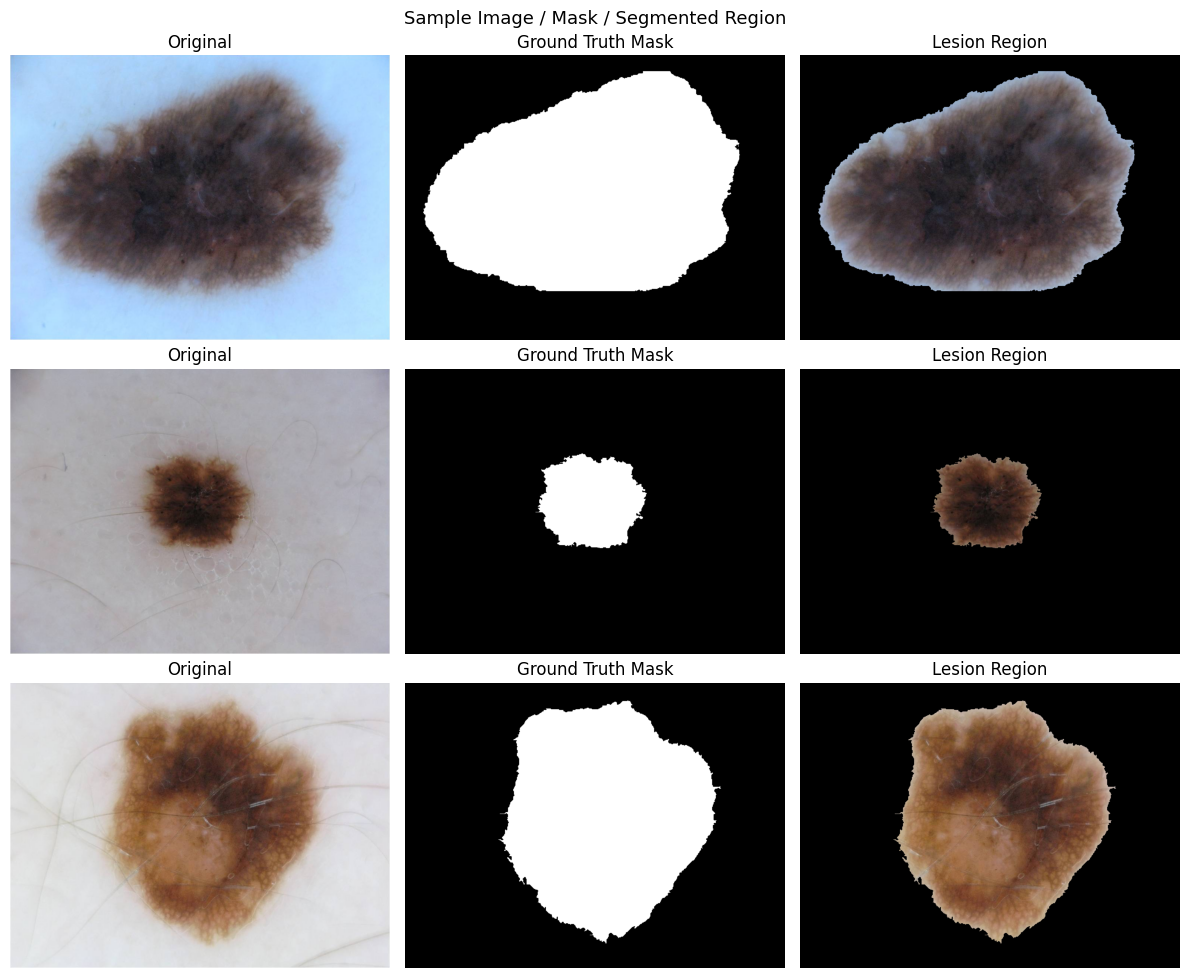

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

sample_names = common[:3]

for i, name in enumerate(sample_names):
    img = cv2.cvtColor(cv2.imread(str(image_map[name])), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(mask_map[name]), cv2.IMREAD_GRAYSCALE)
    
    # Overlay: show lesion region
    overlay = img.copy()
    overlay[mask == 0] = [0, 0, 0]
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Lesion Region")
    axes[i, 2].axis("off")

plt.suptitle("Sample Image / Mask / Segmented Region", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "segmentation_samples.png", dpi=150, bbox_inches="tight")
plt.show()

The masks cleanly delineate lesion boundaries. Images show varying lesion sizes relative to the frame — a key reason why segmentation helps: it removes distracting background skin and focuses the classifier on the lesion itself.

## 3. Mask Statistics
We measure what fraction of each image is covered by the lesion mask. This informs whether the mask is a reliable ROI.

In [8]:
coverage_list = []

for name in common[:200]:  # sample 200 for speed
    mask = cv2.imread(str(mask_map[name]), cv2.IMREAD_GRAYSCALE)
    coverage = (mask > 127).mean()
    coverage_list.append(coverage)

coverage_arr = np.array(coverage_list)
print(f"Lesion coverage (fraction of image):")
print(f"  Mean:   {coverage_arr.mean():.3f}")
print(f"  Median: {np.median(coverage_arr):.3f}")
print(f"  Min:    {coverage_arr.min():.3f}")
print(f"  Max:    {coverage_arr.max():.3f}")

Lesion coverage (fraction of image):
  Mean:   0.310
  Median: 0.280
  Min:    0.015
  Max:    0.932


## 4. Preprocessing Function for Segmentation Data
We resize both image and mask to 256×256. For masks, INTER_NEAREST is used to preserve binary values without introducing interpolation artifacts at edges.

In [9]:
def preprocess_image_and_mask(img_path, mask_path, target_size=TARGET_SIZE):
    img = cv2.imread(str(img_path))
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)
    
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
    
    # Binarize mask
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    
    return img, mask

In [10]:
# Verify the function on one pair
test_name = common[0]
test_img, test_mask = preprocess_image_and_mask(image_map[test_name], mask_map[test_name])

print(f"Image shape: {test_img.shape}, dtype: {test_img.dtype}")
print(f"Mask shape:  {test_mask.shape}, unique values: {np.unique(test_mask)}")

Image shape: (256, 256, 3), dtype: uint8
Mask shape:  (256, 256), unique values: [  0 255]


## 5. Train / Validation / Test Splits

In [11]:
# 70/15/15 split
names_train, names_temp = train_test_split(common, test_size=0.30, random_state=42)
names_val,   names_test = train_test_split(names_temp, test_size=0.50, random_state=42)

print(f"Train: {len(names_train)}, Val: {len(names_val)}, Test: {len(names_test)}")

Train: 1815, Val: 389, Test: 390


## 6. Save Preprocessed Images and Masks
We save processed images and masks to `data/processed/segmentation/` with the split structure expected by BCDU-Net training.

In [12]:
def save_split(names, split_name):
    img_out  = PROCESSED_SEG_DIR / split_name / "images"
    mask_out = PROCESSED_SEG_DIR / split_name / "masks"
    img_out.mkdir(parents=True, exist_ok=True)
    mask_out.mkdir(parents=True, exist_ok=True)
    
    count = 0
    for name in names:
        img, mask = preprocess_image_and_mask(image_map[name], mask_map[name])
        cv2.imwrite(str(img_out  / f"{name}.jpg"),  img)
        cv2.imwrite(str(mask_out / f"{name}.png"), mask)
        count += 1
    
    return count

In [13]:
n_train = save_split(names_train, "train")
print(f"Train saved: {n_train}")

n_val = save_split(names_val, "val")
print(f"Val saved:   {n_val}")

n_test = save_split(names_test, "test")
print(f"Test saved:  {n_test}")

Train saved: 1815
Val saved:   389
Test saved:  390


## 7. Save Split Metadata

In [14]:
seg_split_df = pd.DataFrame({
    "name": common,
    "split": (["train"] * len(names_train) +
              ["val"]   * len(names_val)   +
              ["test"]  * len(names_test))
})

seg_split_df.to_csv(DATA_DIR / "segmentation_splits.csv", index=False)
print("Segmentation split CSV saved.")

Segmentation split CSV saved.


In [15]:
seg_summary = {
    "total_pairs": len(common),
    "target_size": list(TARGET_SIZE),
    "splits": {"train": n_train, "val": n_val, "test": n_test},
    "output_dir": str(PROCESSED_SEG_DIR)
}

with open(RESULTS_DIR / "segmentation_preprocessing_summary.json", "w") as f:
    json.dump(seg_summary, f, indent=2)

print("Segmentation preprocessing complete.")

Segmentation preprocessing complete.
